In [1]:

import os
import random
import requests
import warnings
from datetime import datetime
from datetime import datetime, timedelta

import holidays
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
import itertools
from datetime import timedelta


# Suppress warnings
warnings.filterwarnings('ignore')

# Statistical and ML libraries
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import VarianceThreshold
from sklearn.feature_selection import SelectKBest, f_classif

# Time series specific libraries
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
from scipy import stats 
# Scikit-learn utilities
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Deep learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam

import warnings
warnings.filterwarnings('ignore')

In [ ]:
final_df = pd.read_csv(r'C:\Users\TPWODL\New folder_Content\DeepLearning_TimeSeries_LSTM_End_To_End\data\raw\PowerLoad_Dataset.csv')

In [4]:
final_df

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
0,01-01-2018 01:00,493.09,20.47,66.90,10.35,0.51,1,0,508.96,519.14
1,01-01-2018 04:00,488.29,27.66,58.72,7.86,0.02,1,0,522.95,533.41
2,01-01-2018 07:00,538.37,15.35,36.77,4.67,0.05,1,0,527.55,538.10
3,01-01-2018 13:00,404.34,22.89,83.71,11.05,0.22,1,0,506.71,516.85
4,02-01-2018 14:00,433.59,20.38,43.12,0.51,0.18,2,0,481.05,498.31
...,...,...,...,...,...,...,...,...,...,...
9995,29-06-2023 16:00,549.45,41.41,51.86,1.89,0.00,4,0,509.40,511.15
9996,29-06-2023 17:00,513.91,26.63,34.00,7.73,0.42,4,0,508.86,511.26
9997,30-06-2023 03:00,582.84,21.08,32.43,12.56,0.05,5,0,525.95,515.83
9998,30-06-2023 12:00,480.59,19.23,46.33,14.09,0.00,5,0,525.80,515.69


In [5]:
final_df.columns

Index(['Timestamp', 'Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm', 'DayOfWeek', 'HolidayFlag',
       'Daily_PostDispatch_Load', 'Weekly_PreDispatch_Projection'],
      dtype='object')

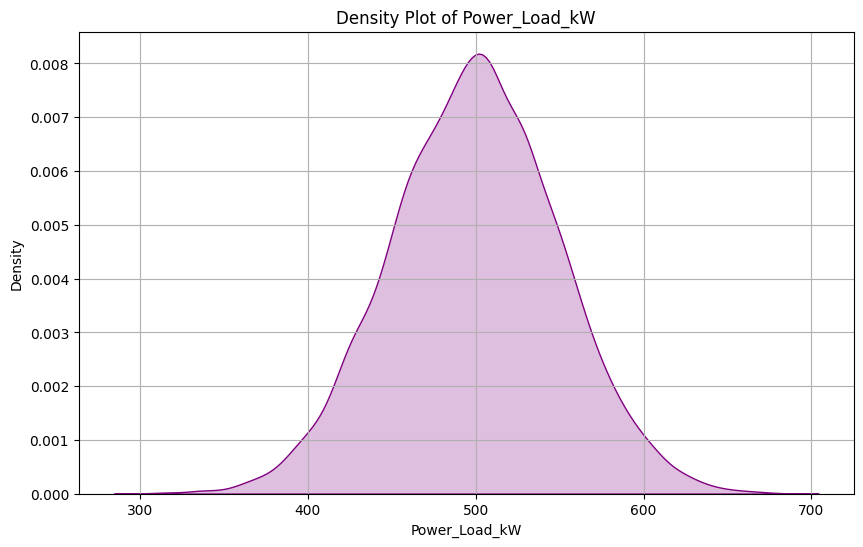

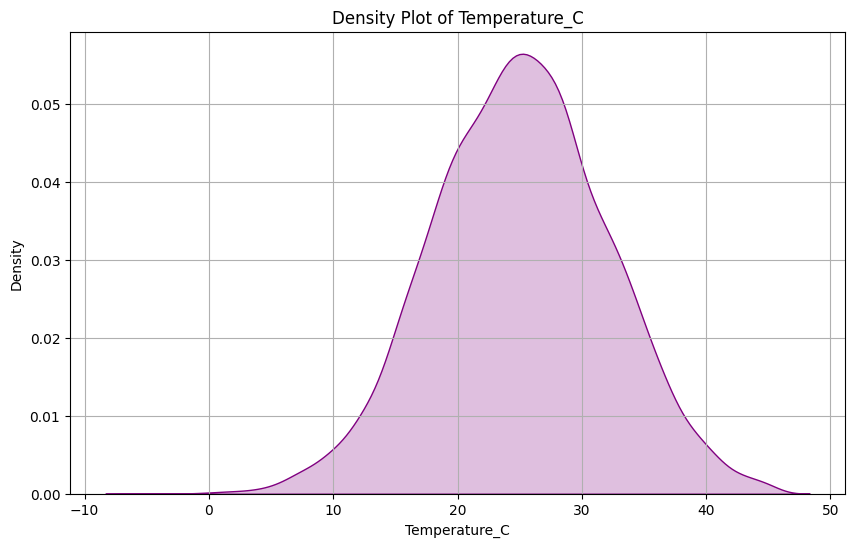

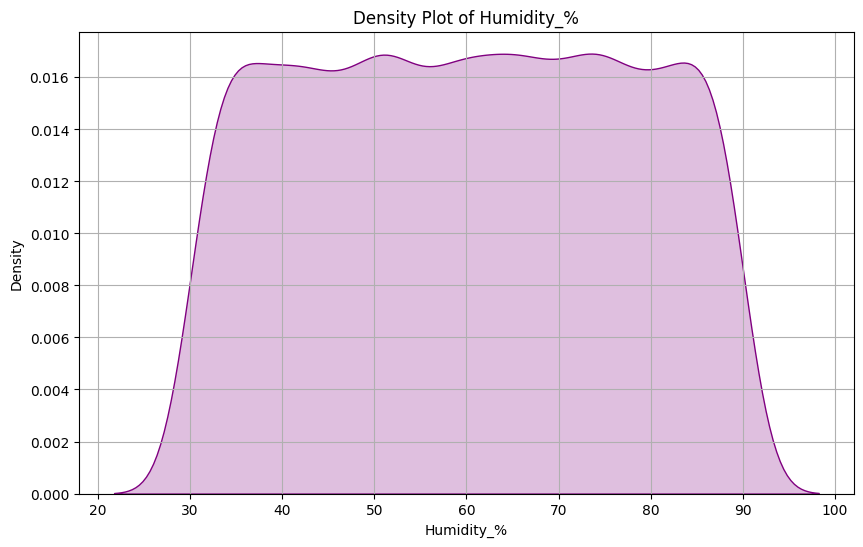

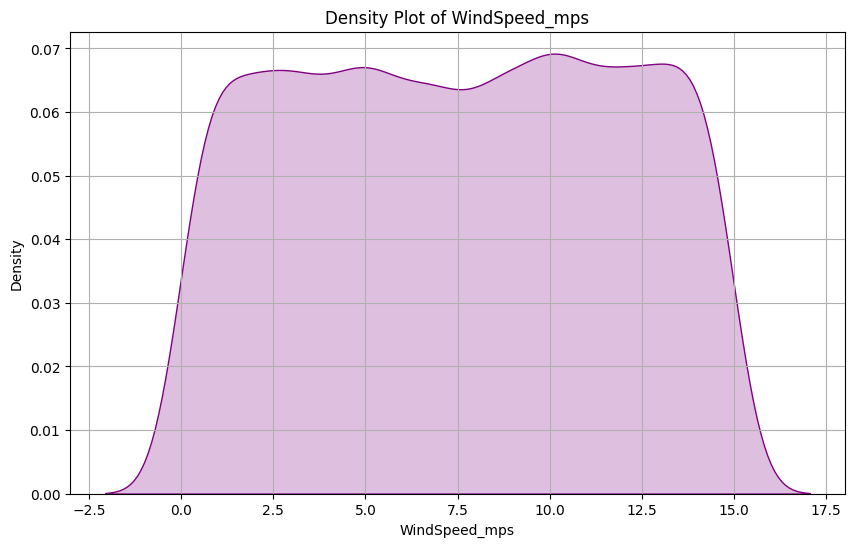

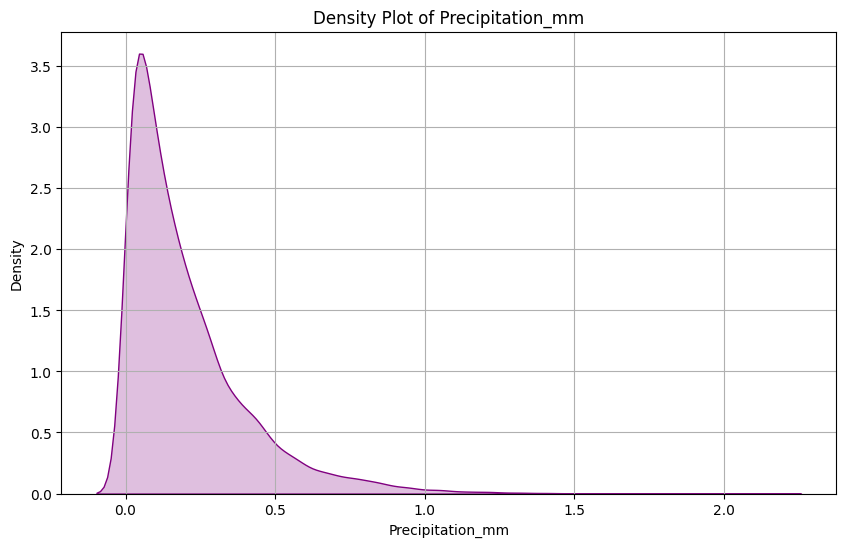

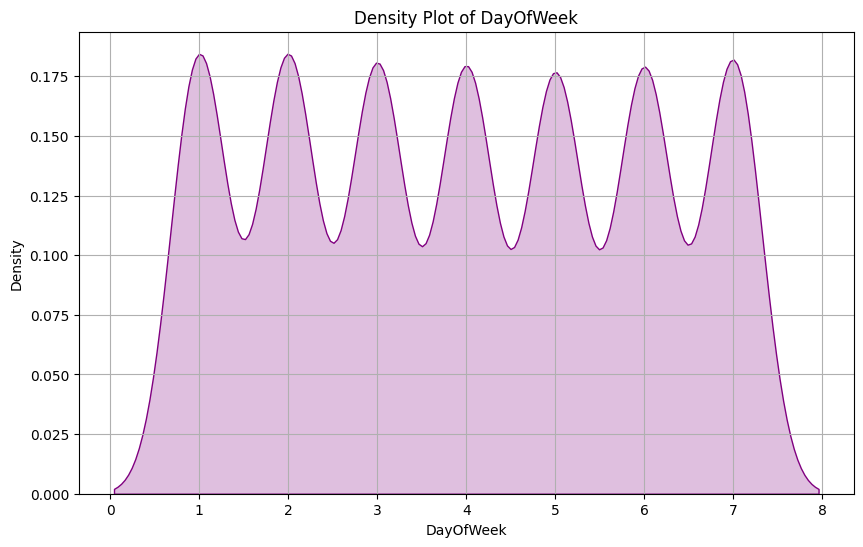

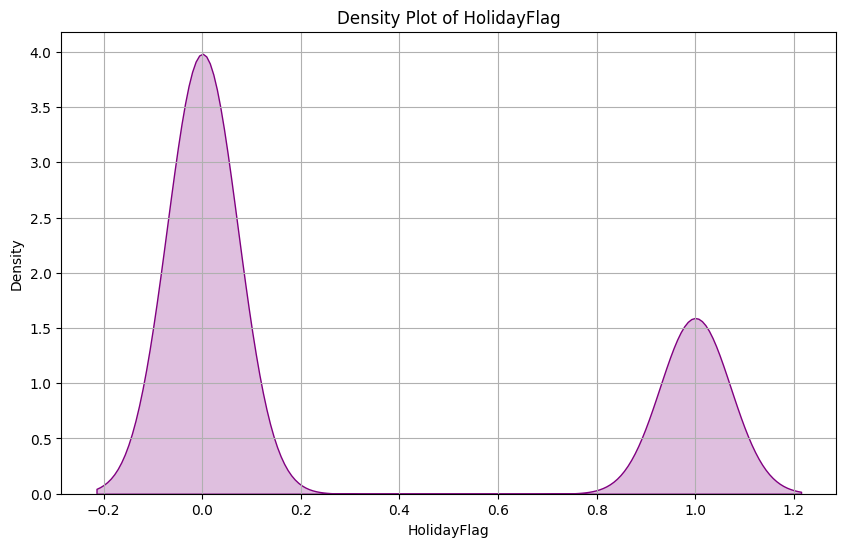

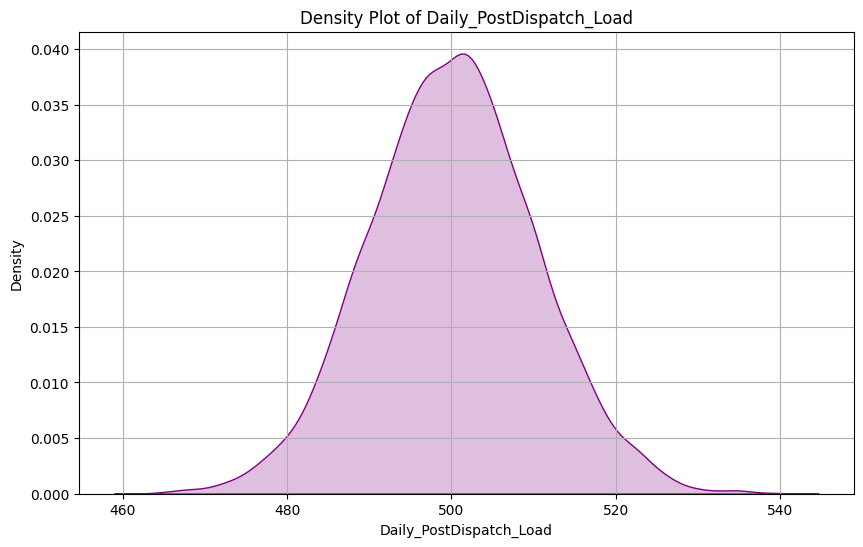

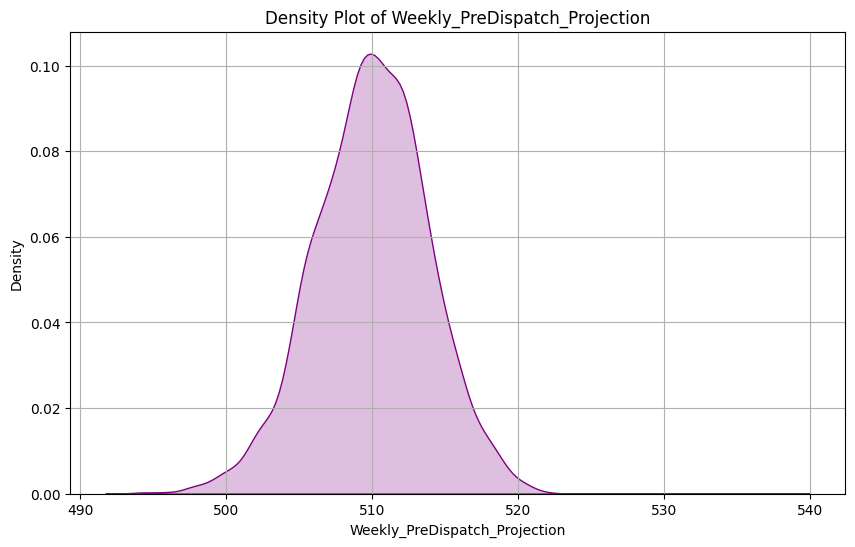

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of columns to plot
columns_to_plot = ['Power_Load_kW', 'Temperature_C', 'Humidity_%',
       'WindSpeed_mps', 'Precipitation_mm', 'DayOfWeek', 'HolidayFlag',
       'Daily_PostDispatch_Load', 'Weekly_PreDispatch_Projection']

# Loop through each column and plot KDE
for col in columns_to_plot:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(final_df[col], shade=True, color='purple')
    plt.title(f'Density Plot of {col}')
    plt.xlabel(col)
    plt.ylabel('Density')
    plt.grid(True)
    plt.show()